# GCN vs. Boosted Forest vs. Linear Regression (ON_FOOT surrogate)

Compares the onfoot GCN (`model_architecture.GCNResNet`, from `scripts/train_onfoot.py`)
against two non-graph baselines trained on the same 29-feature-per-TAZ input, same 7
POI-category output, same train/val/test split: the Boosted Forest
(`qol_surrogate.baseline_onfoot`, from `scripts/train_baseline_onfoot.py`) and a
Multiple Linear Regression (`qol_surrogate.baseline_linear_onfoot`, from
`scripts/train_baseline_linear_onfoot.py`). Both baselines flatten the whole
scenario (all 277 TAZs' features) into one input vector; the graph is removed
entirely.

Unlike `notebooks/compare_baseline.ipynb` (the old 21-channel version), this
notebook doesn't recompute anything live - `scripts/evaluate_onfoot.py`,
`scripts/evaluate_baseline_onfoot.py`, and `scripts/evaluate_baseline_linear_onfoot.py`
already save a TAZ-level `eval_results.pkl` into each run's own folder (the per-TAZ
C-index computation alone can take tens of minutes, so it's only ever computed once,
not per notebook run). This notebook just loads and compares those three pickles.

In [1]:
import glob
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from qol_surrogate.data_onfoot import ZONES_FILE, load_hexes, build_taz_geometries

/home/mmego/micromamba/envs/maat/lib/python3.11/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()


In [2]:
GCN_MODELS_DIR = "../models"
BASELINE_MODELS_DIR = "../models/baseline_onfoot"
LINEAR_MODELS_DIR = "../models/baseline_linear_onfoot"

gcn_run_dir = sorted(d for d in glob.glob(os.path.join(GCN_MODELS_DIR, "gcn_resnet_onfoot_*")) if os.path.isdir(d))[-1]
baseline_run_dir = sorted(d for d in glob.glob(os.path.join(BASELINE_MODELS_DIR, "gbm_onfoot_*")) if os.path.isdir(d))[-1]
linear_run_dir = sorted(d for d in glob.glob(os.path.join(LINEAR_MODELS_DIR, "linear_onfoot_*")) if os.path.isdir(d))[-1]

print(f"GCN run:      {gcn_run_dir}")
print(f"Baseline run: {baseline_run_dir}")
print(f"Linear run:   {linear_run_dir}")

GCN run:      ../models/gcn_resnet_onfoot_20260821_090546
Baseline run: ../models/baseline_onfoot/gbm_onfoot_20260822_115835
Linear run:   ../models/baseline_linear_onfoot/linear_onfoot_20260824_170225


In [3]:
def load_eval_results(run_dir, build_script):
    results_path = os.path.join(run_dir, "eval_results.pkl")
    if not os.path.exists(results_path):
        raise FileNotFoundError(
            f"{results_path} doesn't exist yet - run `python {build_script} {run_dir}` first, "
            f"then re-run this cell."
        )
    with open(results_path, "rb") as f:
        return pickle.load(f)


gcn_results = load_eval_results(gcn_run_dir, "scripts/evaluate_onfoot.py")
baseline_results = load_eval_results(baseline_run_dir, "scripts/evaluate_baseline_onfoot.py")
linear_results = load_eval_results(linear_run_dir, "scripts/evaluate_baseline_linear_onfoot.py")
print("Loaded all three eval_results.pkl")

Loaded all three eval_results.pkl


## Pooled TAZ-level accuracy (all 277 zones combined)

Both deviation (what each model is actually trained to predict) and absolute
(deviation + dry baseline).

In [4]:
pooled = pd.DataFrame({
    "gcn_deviation":      gcn_results["taz"]["deviation"]["overall"],
    "baseline_deviation": baseline_results["taz"]["deviation"]["overall"],
    "linear_deviation":   linear_results["taz"]["deviation"]["overall"],
    "gcn_absolute":       gcn_results["taz"]["absolute"]["overall"],
    "baseline_absolute":  baseline_results["taz"]["absolute"]["overall"],
    "linear_absolute":    linear_results["taz"]["absolute"]["overall"],
})
pooled

,gcn_deviation,baseline_deviation,linear_deviation,gcn_absolute,baseline_absolute,linear_absolute
r2,0.978354,0.994661,0.562174,0.997937,0.999491,0.958270
mae,0.315009,0.136077,1.351067,0.315009,0.136077,1.351067
c_index,0.936624,0.974412,0.781647,0.987816,0.995109,0.952691
wape,0.127318,0.054999,0.546064,0.023096,0.009977,0.099060


## Overall accuracy (%)

Same composite score used in `maat_rl_intro-1/compare_models_mcosta.ipynb`: the mean of
R2, (100 - WAPE), and C-index, each expressed on a 0-100 "% of best possible" scale.
R2 and C-index are already 0-1 with 1.0 = perfect, so *100 puts them on that scale directly.
WAPE is already a percentage but is an *error* (lower = better), so it's inverted to
(100 - WAPE) first, making all three higher-is-better before averaging. Computed from the
pooled (all TAZs, all POI categories), absolute-accessibility overall metrics.

In [5]:
def overall_accuracy_pct(overall_metrics):
    r2, wape, c_index = overall_metrics["r2"], overall_metrics["wape"], overall_metrics["c_index"]
    return (r2 * 100 + (100 - wape * 100) + c_index * 100) / 3


overall_acc = {
    "GCN": overall_accuracy_pct(gcn_results["taz"]["absolute"]["overall"]),
    "Boosted Forest": overall_accuracy_pct(baseline_results["taz"]["absolute"]["overall"]),
    "Linear Regression": overall_accuracy_pct(linear_results["taz"]["absolute"]["overall"]),
}
for name, acc in overall_acc.items():
    print(f"{name}: {acc:.1f}% overall accuracy")

GCN: 98.8% overall accuracy
Boosted Forest: 99.5% overall accuracy
Linear Regression: 93.7% overall accuracy


## City-wide accuracy, by POI category

R2, WAPE, and C-index computed once across all 277 zones combined (absolute
accessibility) - one bar triple per POI category, GCN vs. Boosted Forest vs.
Linear Regression.

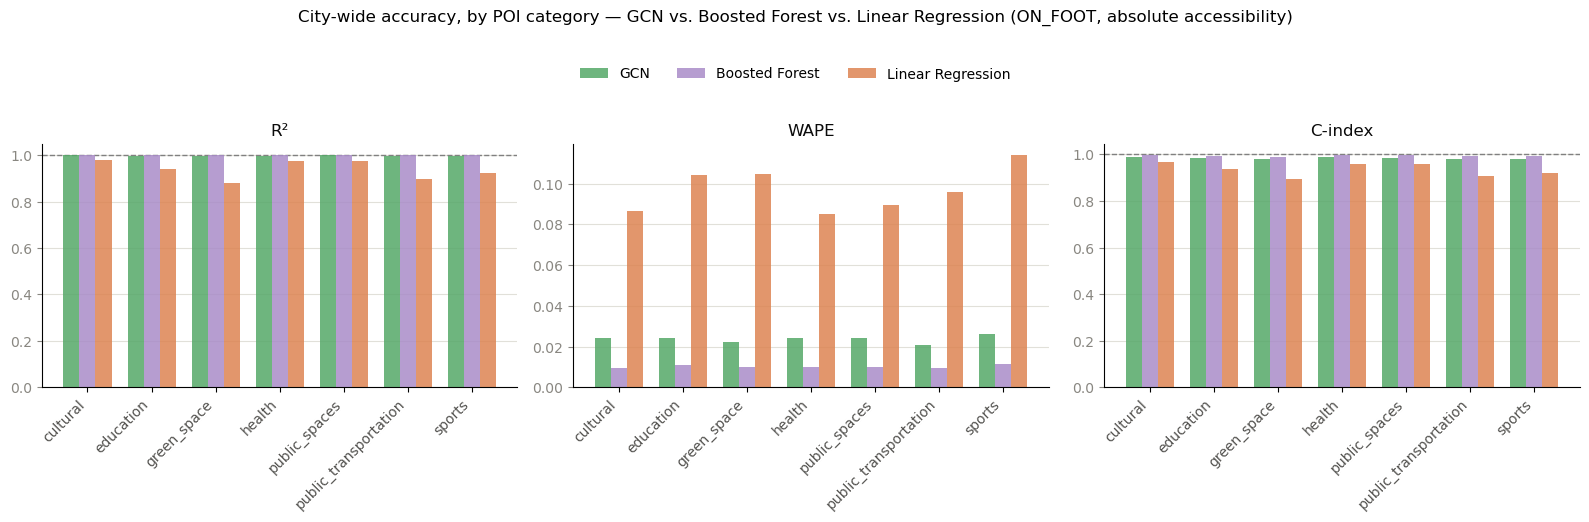

In [6]:
POI_CATEGORIES = ['cultural', 'education', 'green_space', 'health',
                   'public_spaces', 'public_transportation', 'sports']

METRICS = ["r2", "wape", "c_index"]
METRIC_LABELS = {"r2": "R\u00b2", "wape": "WAPE", "c_index": "C-index"}
METRICS_WITH_MAX_1 = {"r2", "c_index"}

COLOR_GCN = "#55A868"       # green - same convention as the old compare_baseline.ipynb
COLOR_BASELINE = "#A98CC8"  # pastel purple
COLOR_LINEAR = "#DD8452"    # muted amber - distinct from the green/purple pair above
INK_MUTED = "#898781"
INK_SECONDARY = "#52514e"
GRID_COLOR = "#e1e0d9"
BAR_WIDTH = 0.25

# (results key, display label, color) - shared ordering for every multi-model plot below
MODELS = [
    ("gcn", "GCN", COLOR_GCN),
    ("baseline", "Boosted Forest", COLOR_BASELINE),
    ("linear", "Linear Regression", COLOR_LINEAR),
]
RESULTS_BY_KEY = {"gcn": gcn_results, "baseline": baseline_results, "linear": linear_results}

x = np.arange(len(POI_CATEGORIES))
offsets = [-BAR_WIDTH, 0, BAR_WIDTH]

fig, axes = plt.subplots(1, len(METRICS), figsize=(16, 4.5))

for ax, metric in zip(axes, METRICS):
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    for (key, label, color), offset in zip(MODELS, offsets):
        vals = [RESULTS_BY_KEY[key]["taz"]["absolute"]["per_channel"][c][metric] for c in POI_CATEGORIES]
        ax.bar(x + offset, vals, width=BAR_WIDTH, color=color, alpha=0.85, zorder=2, label=label)

    if metric in METRICS_WITH_MAX_1:
        ax.axhline(1.0, color="gray", linewidth=1, linestyle="--", zorder=1)

    ax.set_xticks(x)
    ax.set_xticklabels(POI_CATEGORIES, rotation=45, ha="right", color=INK_SECONDARY)
    ax.set_title(METRIC_LABELS[metric], color="#0b0b0b")
    ax.tick_params(axis="y", colors=INK_MUTED)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=False)
fig.suptitle("City-wide accuracy, by POI category \u2014 GCN vs. Boosted Forest vs. Linear Regression (ON_FOOT, absolute accessibility)", y=1.15)
fig.tight_layout()
plt.show()

## Per-TAZ accuracy

Per-TAZ R2, WAPE, and C-index (absolute accessibility, pooled over the 7 POI
categories and every test scenario within each zone) - GCN vs. Boosted Forest
vs. Linear Regression.

In [7]:
per_taz_gcn = gcn_results["taz_per_taz"]
per_taz_baseline = baseline_results["taz_per_taz"]
per_taz_linear = linear_results["taz_per_taz"]
per_taz_gcn["r2"].describe()

,ON_FOOT
count,277.000000
mean,0.995175
std,0.004672
min,0.960361
25%,0.994156
50%,0.996354
75%,0.997829
max,0.999361


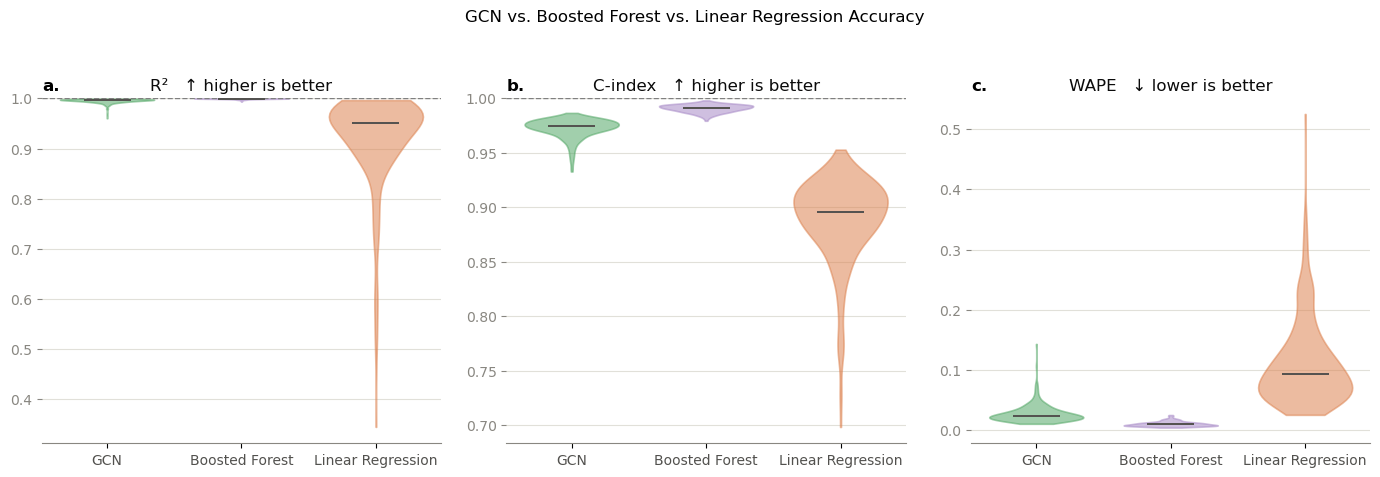

In [8]:
VIOLIN_METRICS = ["r2", "c_index", "wape"]  # the two 1.0-capped metrics side by side, WAPE (uncapped) last
VIOLIN_TITLES = {
    "r2": "R\u00b2   \u2191 higher is better",
    "c_index": "C-index   \u2191 higher is better",
    "wape": "WAPE   \u2193 lower is better",
}
VIOLIN_LABELS = {"r2": "a.", "c_index": "b.", "wape": "c."}

PER_TAZ_BY_KEY = {"gcn": per_taz_gcn, "baseline": per_taz_baseline, "linear": per_taz_linear}

fig, axes = plt.subplots(1, len(VIOLIN_METRICS), figsize=(14, 4.5))

for ax, metric in zip(axes, VIOLIN_METRICS):
    data = [PER_TAZ_BY_KEY[key][metric]["ON_FOOT"].dropna().to_numpy() for key, _, _ in MODELS]

    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    vp = ax.violinplot(data, positions=[0, 1, 2], widths=0.7,
                        showmedians=True, showextrema=False)
    for body, (_, _, color) in zip(vp["bodies"], MODELS):
        body.set_facecolor(color); body.set_edgecolor(color); body.set_alpha(0.55); body.set_linewidth(1.2)
    vp["cmedians"].set_color(INK_SECONDARY); vp["cmedians"].set_linewidth(1.4)

    if metric in METRICS_WITH_MAX_1:
        ax.axhline(1.0, color="gray", linewidth=1, linestyle="--", zorder=1)
        ymin, _ = ax.get_ylim()
        ax.set_ylim(ymin, 1.0)  # capped - nothing plotted above 1.0 is shown

    ax.set_xticks([0, 1, 2]); ax.set_xticklabels([label for _, label, _ in MODELS], color=INK_SECONDARY)
    ax.set_title(VIOLIN_LABELS[metric], loc="left", fontweight="bold")
    ax.set_title(VIOLIN_TITLES[metric], loc="center", color="#0b0b0b")
    ax.tick_params(axis="y", colors=INK_MUTED)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(INK_MUTED)

fig.suptitle("GCN vs. Boosted Forest vs. Linear Regression Accuracy", y=1.05)
fig.tight_layout()
plt.show()

## Per-TAZ maps

Where geographically each model struggles most (R2, absolute accessibility).
Linear Regression's much wider R2 range pulls the shared color scale wider
than the GCN/Boosted Forest-only comparison used before - the same scale is
used across all three panels so they stay directly comparable.

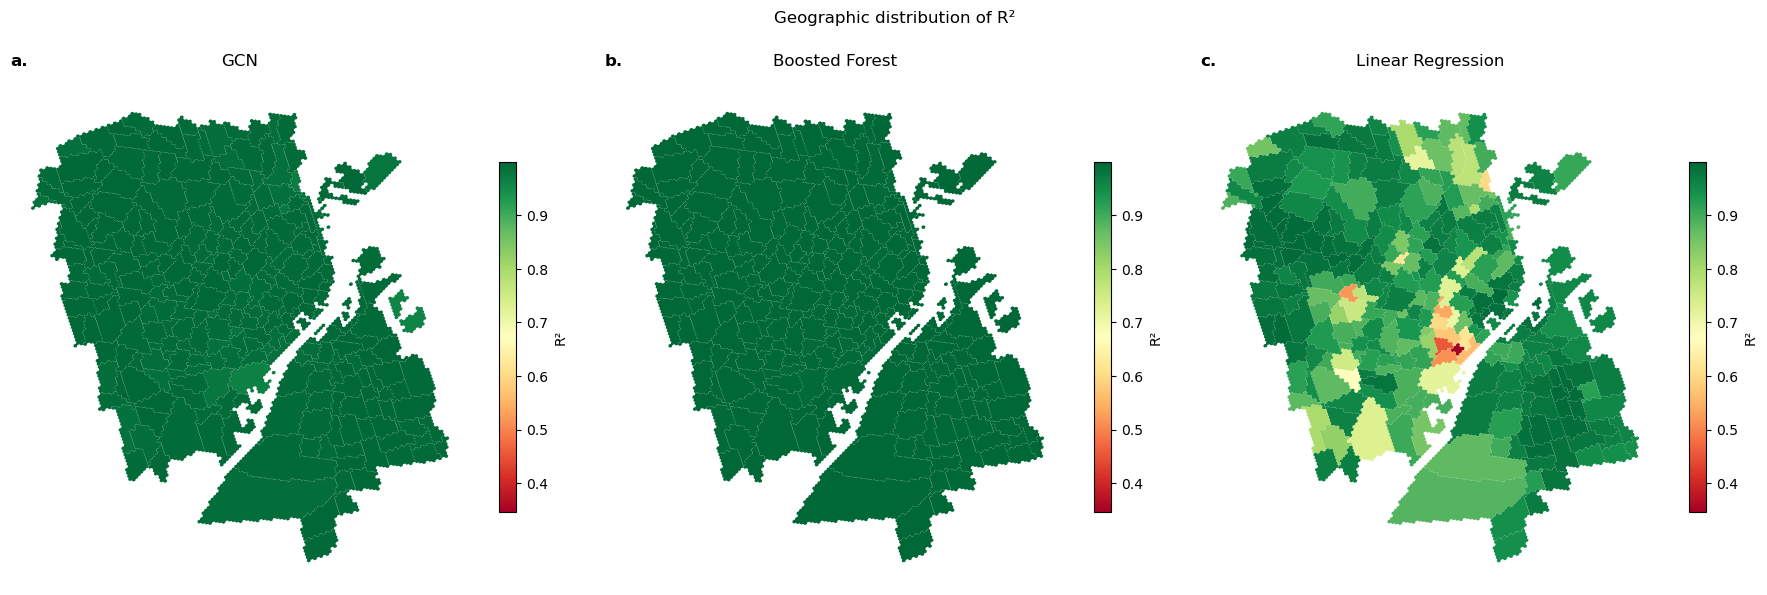

In [9]:
hexes = load_hexes(ZONES_FILE)
tazes = build_taz_geometries(hexes)

r2_by_key = {key: PER_TAZ_BY_KEY[key]["r2"]["ON_FOOT"] for key, _, _ in MODELS}

r2_vmin = min(s.min() for s in r2_by_key.values())
r2_vmax = max(s.max() for s in r2_by_key.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
panel_labels = ["a.", "b.", "c."]

for ax, (key, title, _), label in zip(axes, MODELS, panel_labels):
    df = tazes.join(r2_by_key[key].rename("ON_FOOT"))
    df.plot(column="ON_FOOT", cmap="RdYlGn", vmin=r2_vmin, vmax=r2_vmax, legend=True, ax=ax,
             legend_kwds={"label": "R\u00b2", "shrink": 0.65})
    ax.set_title(label, loc="left", fontweight="bold")
    ax.set_title(title, loc="center")
    ax.set_axis_off()

fig.suptitle("Geographic distribution of R\u00b2", y=1.02)
plt.tight_layout()
plt.show()

### GCN summary: geographic distribution of R2

A standalone view of the GCN's own per-TAZ R2, without the baseline for comparison -
for use on its own (e.g. in a presentation slide). Keeps the familiar `RdYlGn` scale but truncated to only its upper (green)
half: R2 here only ranges from about 0.96 to 1.0 (a narrow, uniformly strong
band), so the red/orange/yellow end is never actually reached - using the full
colormap would still paint the lowest value in that band an alarming red, even
though 0.96 is a strong score.

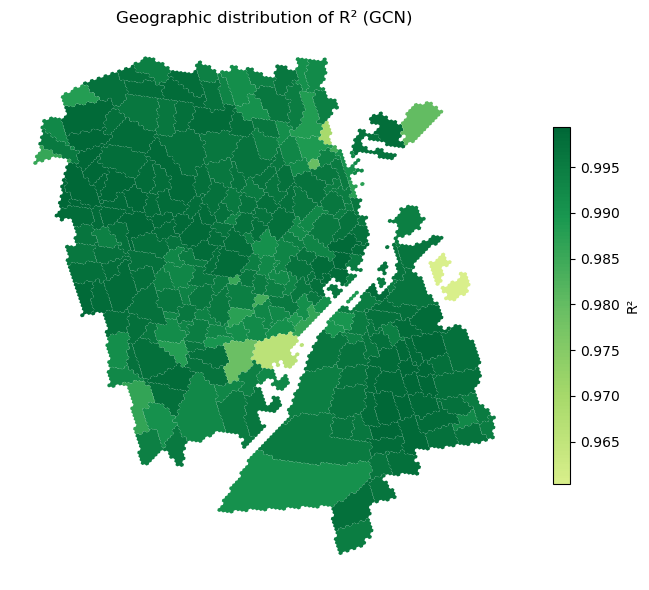

In [10]:
import matplotlib.colors as mcolors

# Only the upper (green) half of RdYlGn - keeps the familiar red-green scale's
# "green" while skipping the yellow/orange/red end entirely, so a still-strong
# score like 0.96 doesn't get painted an alarming red just because it's the
# lowest value in a narrow, uniformly-strong band.
_rdylgn = plt.get_cmap("RdYlGn")
GREEN_ONLY = mcolors.LinearSegmentedColormap.from_list("RdYlGn_upper_green", _rdylgn(np.linspace(0.6, 1.0, 256)))

fig, ax = plt.subplots(figsize=(7, 6))
df_gcn_r2 = tazes.join(per_taz_gcn["r2"])
df_gcn_r2.plot(column="ON_FOOT", cmap=GREEN_ONLY, legend=True, ax=ax,
               legend_kwds={"label": "R\u00b2", "shrink": 0.65})
ax.set_title("Geographic distribution of R\u00b2 (GCN)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Inference latency: raw input to TAZ-resolution prediction

Single-scenario (batch size 1) latency for all three models, on the *same* TAZ-resolution scenario, from raw (un-normalized) input to absolute accessibility - matches how a single RL step would call any of them. Starts from an already-TAZ-aggregated 29-feature scenario, not full edge-resolution water depth - `qol_surrogate.inference.QoL_surrogate.predict()` is the true edge-to-prediction production entry point for the GCN if that fuller pipeline needs timing too, but it needs raw edge-resolution data this notebook doesn't otherwise load.

The GCN is one shared forward pass over all 277 TAZs at once. The Boosted Forest triggers 7 separate `MultiOutputRegressor.predict()` calls (one per POI category), each internally looping over its own 277 independent per-TAZ tree ensembles - 1939 individual model calls per scenario - so expect it to be substantially slower. Linear Regression is a single shared model (see `qol_surrogate.baseline_linear_onfoot`) - one matrix-vector product, so expect it to be the fastest of the three.

**Note:** this needs trained ON_FOOT Boosted Forest and Linear Regression runs (`models/baseline_onfoot/gbm_onfoot_*`, `models/baseline_linear_onfoot/linear_onfoot_*`) to exist - if either training script hasn't been run yet, this cell (and every cell above it) will fail at the run-directory lookup.

In [11]:
import time

import torch

from qol_surrogate.data_onfoot import (
    DRY_BASELINE_DIR, STATIC_FEATURES_DIR, TAZ_PARQUET_DIR, load_dataset_tensors, split_dataset,
)
from qol_surrogate.inference import load_model

gcn_model, _ = load_model(os.path.join(gcn_run_dir, "model.pt"))
gcn_model.eval()

with open(os.path.join(baseline_run_dir, "model.pkl"), "rb") as f:
    baseline_models = pickle.load(f)["models"]

with open(os.path.join(linear_run_dir, "model.pkl"), "rb") as f:
    linear_model = pickle.load(f)["model"]

# one raw (un-normalized) TAZ-resolution scenario, shared by all three models
with open(os.path.join(STATIC_FEATURES_DIR, "static_features.pkl"), "rb") as f:
    static_features_dict = pickle.load(f)

x, y, y_dry = load_dataset_tensors(static_features_dict, taz_parquet_dir=TAZ_PARQUET_DIR, dry_baseline_dir=DRY_BASELINE_DIR)
_, _, x_test, _, _, _, _, _, _ = split_dataset(x, y)
dry_baseline = y_dry.squeeze(0)  # [277, 7]
x_raw_sample = x_test[0]  # [277, 29] - same scenario for all three models


def gcn_pipeline():
    x_norm = (x_raw_sample - gcn_model.x_mean) / gcn_model.x_std
    out = gcn_model(x_norm, gcn_model.graph_edge_index, gcn_model.graph_edge_weight)
    out_deviation = out * gcn_model.y_std + gcn_model.y_mean
    return out_deviation + gcn_model.dry_baseline


x_raw_flat = x_raw_sample.reshape(1, -1).numpy()


def baseline_pipeline():
    # NOTE: deliberately NOT using baseline_onfoot.predict() here - that helper's
    # MultiOutputRegressor.predict() calls use n_jobs=-1, which is the right choice
    # for batch evaluation (thousands of rows) but catastrophically wrong for a
    # single row: multiprocess dispatch overhead across 277 trivial per-TAZ
    # predictions x 7 channels measured ~410s/call, vs. ~4.6s calling each
    # sub-estimator directly in a loop - the overhead was ~100% dispatch cost, not
    # real compute. Sequential is what an actual single-scenario RL-loop call would
    # look like anyway.
    preds = np.stack([
        np.stack([est.predict(x_raw_flat)[0] for est in baseline_models[cat].estimators_])
        for cat in POI_CATEGORIES
    ], axis=-1)  # [277, 7]
    return torch.from_numpy(preds).float() + dry_baseline


def linear_pipeline():
    # single shared model, one matrix-vector product - no per-channel/per-TAZ loop needed
    n_taz = linear_model.coef_.shape[0] // len(POI_CATEGORIES)
    preds = linear_model.predict(x_raw_flat).reshape(len(POI_CATEGORIES), n_taz).T  # [277, 7]
    return torch.from_numpy(preds).float() + dry_baseline


# Rough factor only, not a precise benchmark.
N_SAMPLES_GCN, N_WARMUP_GCN = 200, 10
N_SAMPLES_BASELINE, N_WARMUP_BASELINE = 20, 3
N_SAMPLES_LINEAR, N_WARMUP_LINEAR = 200, 10

with torch.no_grad():
    for _ in range(N_WARMUP_GCN):
        gcn_pipeline()
    gcn_times = []
    for _ in range(N_SAMPLES_GCN):
        t0 = time.perf_counter()
        gcn_pipeline()
        gcn_times.append(time.perf_counter() - t0)
gcn_times = np.array(gcn_times) * 1000  # ms

for _ in range(N_WARMUP_BASELINE):
    baseline_pipeline()
baseline_times = []
for _ in range(N_SAMPLES_BASELINE):
    t0 = time.perf_counter()
    baseline_pipeline()
    baseline_times.append(time.perf_counter() - t0)
baseline_times = np.array(baseline_times) * 1000  # ms

for _ in range(N_WARMUP_LINEAR):
    linear_pipeline()
linear_times = []
for _ in range(N_SAMPLES_LINEAR):
    t0 = time.perf_counter()
    linear_pipeline()
    linear_times.append(time.perf_counter() - t0)
linear_times = np.array(linear_times) * 1000  # ms

print(f"GCN               (n={N_SAMPLES_GCN}): mean {gcn_times.mean():.3f} ms, median {np.median(gcn_times):.3f} ms, "
      f"std {gcn_times.std():.3f} ms")
print(f"Boosted Forest    (n={N_SAMPLES_BASELINE}):  mean {baseline_times.mean():.3f} ms, median {np.median(baseline_times):.3f} ms, "
      f"std {baseline_times.std():.3f} ms")
print(f"Linear Regression (n={N_SAMPLES_LINEAR}): mean {linear_times.mean():.3f} ms, median {np.median(linear_times):.3f} ms, "
      f"std {linear_times.std():.3f} ms")
print(f"Boosted Forest is {baseline_times.mean() / gcn_times.mean():.1f}x slower than the GCN, per scenario (rough factor)")
print(f"Linear Regression is {gcn_times.mean() / linear_times.mean():.1f}x faster than the GCN, per scenario (rough factor)")

GCN               (n=200): mean 8.734 ms, median 6.378 ms, std 5.616 ms
Boosted Forest    (n=20):  mean 6108.281 ms, median 6070.049 ms, std 458.156 ms
Linear Regression (n=200): mean 9.031 ms, median 5.994 ms, std 11.883 ms
Boosted Forest is 699.4x slower than the GCN, per scenario (rough factor)
Linear Regression is 1.0x faster than the GCN, per scenario (rough factor)


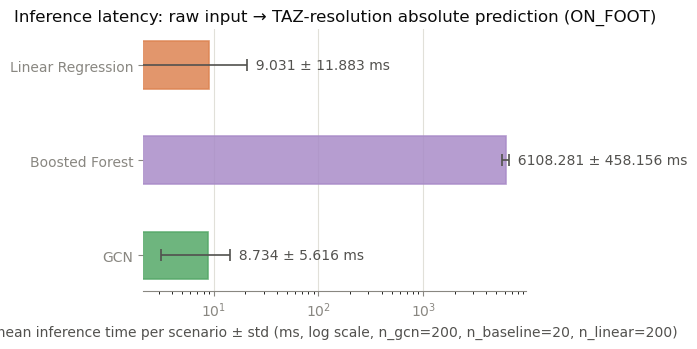

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.6))

labels = [label for _, label, _ in MODELS]
means = [gcn_times.mean(), baseline_times.mean(), linear_times.mean()]
stds = [gcn_times.std(), baseline_times.std(), linear_times.std()]
colors = [color for _, _, color in MODELS]

bars = ax.barh(labels, means, xerr=stds, color=colors, alpha=0.85, edgecolor=colors, linewidth=1.2, height=0.5,
                error_kw=dict(ecolor=INK_SECONDARY, elinewidth=1.2, capsize=4, capthick=1.2), zorder=2)
ax.set_xscale("log")
ax.set_xlabel(f"mean inference time per scenario \u00b1 std (ms, log scale, "
              f"n_gcn={N_SAMPLES_GCN}, n_baseline={N_SAMPLES_BASELINE}, n_linear={N_SAMPLES_LINEAR})",
              color=INK_SECONDARY)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8, which="major", zorder=0)  # major only - "both" was too busy on a log axis
ax.set_axisbelow(True)
ax.tick_params(colors=INK_MUTED)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(INK_MUTED)

for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std, bar.get_y() + bar.get_height() / 2, f"  {mean:.3f} \u00b1 {std:.3f} ms",
            va="center", ha="left", color=INK_SECONDARY)

ax.set_title("Inference latency: raw input \u2192 TAZ-resolution absolute prediction (ON_FOOT)", color="#0b0b0b")
fig.tight_layout()
plt.show()